
# House Price Prediction using Linear Regression

A machine learning project that predicts house prices using property features.

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## Dataset Loading

Loading the housing dataset into Pandas.

In [3]:
data = pd.read_csv("HousePricePrediction.csv")

## Data Exploration
## Exploratory Data Analysis

Understanding the structure and characteristics of the dataset.

In [4]:
data.shape
data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


## Data Preprocessing  - Data Cleaning 
- Removed unnecessary columns
- Handled missing values
- Prepared data for modeling

# dropped ID as it does not contribute in price prediction

    


In [5]:
data.drop(['Id'],
             axis=1,
             inplace=True)

# Replacing SalePrice empty values with their mean values

In [6]:
data['SalePrice'] = data['SalePrice'].fillna(
  data['SalePrice'].mean()) 

# Drop records with null values

In [7]:
data = data.dropna()

data.isnull().sum()
data.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


## Feature Engineering

Categorical variables were converted into numerical values using One-Hot Encoding.

In [8]:
cols = ['MSZoning' , 'LotConfig', 'BldgType' , 'Exterior1st']
data = pd.get_dummies(data,columns = cols, drop_first = True)

## Splitting Dataset

80% Training Data
20% Testing Data

In [9]:
from sklearn.model_selection import train_test_split
X  = data.drop("SalePrice",axis = 1)
Y = data["SalePrice"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

In [10]:
X_train.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
2356,20,7441,5,2006,2006,0.0,1461.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1789,30,10800,5,1890,1998,0.0,630.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2371,20,7321,5,1999,2000,0.0,1339.0,True,False,False,...,True,False,False,False,False,False,False,False,False,False
930,20,8925,5,2007,2007,0.0,1466.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2816,20,13050,6,1963,1963,850.0,1000.0,False,False,True,...,False,False,False,False,False,False,False,False,False,True


## Model Training

Using Linear Regression from Scikit-learn.

In [11]:

model = LinearRegression()
model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Evaluation

The model performance was evaluated using:
- R² Score
- MAE
- RMSE
- MAPE

In [12]:
from sklearn.metrics import r2_score , mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np 

Y_pred = model.predict(X_test)
print("R2 Score:", r2_score(Y_test, Y_pred))
print("MAE:", mean_absolute_error(Y_test, Y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, Y_pred)))
print(mean_absolute_percentage_error(Y_test, Y_pred))

R2 Score: 0.3469223785187575
MAE: 32690.891525374307
RMSE: 48797.19470847396
0.20016996577116575


## Visualization

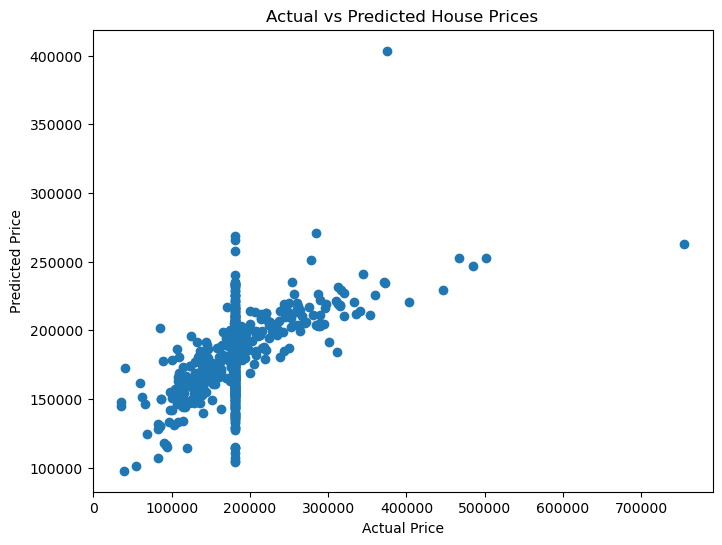

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## Actual vs Predicted House Prices

This scatter plot compares the actual house prices with the prices predicted by the Linear Regression model.

Interpretation:
- Each point represents one house.
- The closer the points are to an imaginary diagonal line, the better the predictions.
- Points far from the diagonal indicate prediction errors.

Observation:
The points are generally clustered around the diagonal trend, indicating that the model captures the relationship between features and house prices reasonably well.

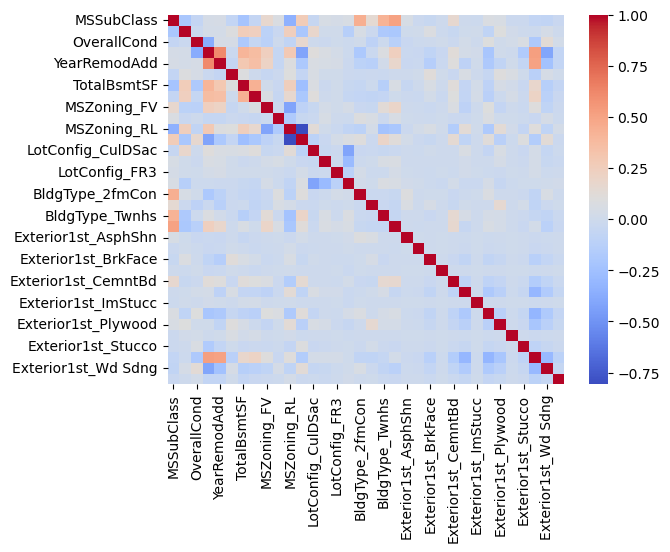

In [17]:
import seaborn as sns

sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm')
plt.show()

## Correlation Heatmap

The heatmap shows the correlation between numerical features.

Interpretation:
- Values close to +1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values near 0 indicate little or no relationship.

Observation:
Features with higher positive correlation to SalePrice are likely to have a stronger influence on house prices and may be useful predictors.

# SalePrice Distribution


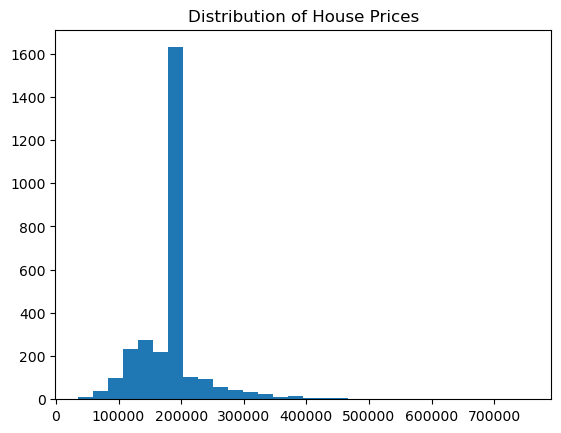

In [18]:
plt.hist(data["SalePrice"], bins=30)
plt.title("Distribution of House Prices")
plt.show()

## Distribution of House Prices

This histogram shows how house prices are distributed in the dataset.

Interpretation:
- Taller bars indicate a larger number of houses within that price range.
- The shape helps identify whether the data is normally distributed or skewed.

Observation:
Most houses are concentrated within a specific price range, while very expensive houses appear less frequently.